# Experiment Runner Notebook
**Multi-Aspect Sentiment Analysis — Ablation Studies & Baseline Comparisons**

Loads shared class definitions from `06_full_model_development.ipynb` via `%run`
(definition-only mode — no data loading or training triggered).

| Section | Contents |
|---|---|
| **1. Setup & Config** | Load `config.yaml`, output paths, device |
| **2. Load Shared Definitions** | `%run` notebook 06 (classes only) |
| **3. Baseline Models** | `PlainRoBERTa`, `DistilBERTBaseline`, `BERTBaseline`, `TFIDFSVMBaseline` |
| **4. Experiment Configs** | A1–A5, A7 ablations + B1–B4 baselines (A6 removed) |
| **5. Experiment Engine** | `ExperimentTrainer`, `run_dl_experiment`, `run_tfidf_svm`, `run_experiments` |
| **6. Run Experiments** | Interactive cells to run any subset |
| **7. Results Analysis** | Tables, bar charts, MSR chart, LaTeX table |


---
## Section 1 - Setup & Configuration
---

In [1]:
# ─────────────────────────────────────────────────────────────────────
# Imports & paths
#
# Standard imports shared across all cells.
# NOTEBOOK_DIR  - the folder this notebook lives in
# ML_ROOT       - ml-research/ root (two levels up from the notebook)
# CONFIG_PATH   - configs/config.yaml (loaded as BASE_CONFIG below)
# NB06_PATH     - path to 06_full_model_development.ipynb (used by %run in Section 2)
# RESULTS_DIR   - outputs/experiments/  (same folder as CLI experiment_runner)
# ALL_RESULTS_PATH - the cumulative results file written after every experiment
# ─────────────────────────────────────────────────────────────────────
import os, sys, json, time, copy, warnings
import numpy as np
import pandas as pd
from pathlib import Path
import yaml

import torch
import torch.nn as nn
from transformers import (
    RobertaTokenizer, BertTokenizer, DistilBertTokenizer,
    RobertaModel, BertModel, DistilBertModel,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, f1_score, matthews_corrcoef,
    precision_recall_fscore_support
)
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# ── Resolve paths ────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path(os.getcwd())
ML_ROOT      = NOTEBOOK_DIR.parent.parent   # ml-research/
CONFIG_PATH  = ML_ROOT / 'configs' / 'config.yaml'
NB06_PATH    = NOTEBOOK_DIR.parent / '02_model_development' /'06_full_model_development.ipynb'

# ── Load base config from YAML ───────────────────────────────────────────────
# BASE_CONFIG is the starting point for every experiment.
# Each ablation/baseline function deep-copies this dict and modifies only
# the settings it wants to change — everything else stays the same.
with open(CONFIG_PATH, 'r') as f:
    BASE_CONFIG = yaml.safe_load(f)

# Convert relative data paths to absolute so the notebook works from any CWD
for key in ('train_path', 'val_path', 'test_path'):
    BASE_CONFIG['data'][key] = str(ML_ROOT / BASE_CONFIG['data'][key])

# Always enable MSR evaluation at baseline config level
BASE_CONFIG.setdefault('experiment', {}).setdefault('evaluate_msr', True)

# ── Output directory ─────────────────────────────────────────────────────────
# Same folder as the CLI experiment_runner.py — all_results.json is shared
RESULTS_DIR      = ML_ROOT / 'outputs' / 'experiments'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
ALL_RESULTS_PATH = RESULTS_DIR / 'all_results.json'

DEVICE = torch.device(BASE_CONFIG['hardware']['device'] if torch.cuda.is_available() else 'cpu')

print(f'Config       : {CONFIG_PATH}')
print(f'Results dir  : {RESULTS_DIR}')
print(f'Results file : {ALL_RESULTS_PATH}')
print(f'Device       : {DEVICE}')
print(f'Aspects      : {BASE_CONFIG["aspects"]["names"]}')


Config       : c:\Users\lucif\Desktop\Clearview\ml-research\configs\config.yaml
Results dir  : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments
Results file : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\all_results.json
Device       : cuda
Aspects      : ['stayingpower', 'texture', 'smell', 'price', 'colour', 'shipping', 'packing']


---
## Section 2 - Load Shared Definitions from Notebook 06

Sets `builtins._NB_RUN_PIPELINE = False` before `%run` so that all execution
cells in `06_full_model_development.ipynb` are skipped - only class/function
definitions are loaded into this notebook's namespace.

---


In [2]:
# ─────────────────────────────────────────────────────────────────────
# How this works:
#
# 1. We write  builtins._NB_RUN_PIPELINE = False  on the shared Python
#    builtins module (visible to all code running in this process).
#
# 2. %run executes every cell in 06_full_model_development.ipynb.
#    The very first cell in 07 reads the flag:
#      RUN_PIPELINE = getattr(builtins, '_NB_RUN_PIPELINE', True)
#    Because we set it to False, RUN_PIPELINE becomes False in 07.
#
# 3. Every 'execution' cell in 06 is wrapped with `if RUN_PIPELINE:`,
#    so data loading, training, and plot cells are all SKIPPED.
#    But class/function definition cells have no guard, so they DO run.
#
# 4. After %run finishes, all classes (MultiAspectSentimentModel, losses,
#    data utils, metrics) are available in THIS notebook's namespace.
#
# 5. We reset the flag to True so we leave no side effects.
# ─────────────────────────────────────────────────────────────────────
import builtins
builtins._NB_RUN_PIPELINE = False   # Tell 06 to skip execution cells

print(f'Loading definitions from {NB06_PATH}...')
%run {NB06_PATH}

builtins._NB_RUN_PIPELINE = True    # Reset flag - leave no side effects

# Verify the most important classes were loaded correctly
assert 'MultiAspectSentimentModel' in dir(), 'MultiAspectSentimentModel not loaded!'
assert 'AspectSpecificLossManager'  in dir(), 'AspectSpecificLossManager not loaded!'
assert 'AspectSentimentEvaluator'   in dir(), 'AspectSentimentEvaluator not loaded!'
assert 'MixedSentimentEvaluator'    in dir(), 'MixedSentimentEvaluator not loaded!'
assert 'create_dataloaders'         in dir(), 'create_dataloaders not loaded!'
assert 'DependencyParser'           in dir(), 'DependencyParser not loaded!'
print('All shared definitions loaded successfully.')


Loading definitions from c:\Users\lucif\Desktop\Clearview\ml-research\notebooks\02_model_development\06_full_model_development.ipynb...
PyTorch  : 2.5.1+cu121
CUDA     : True  (NVIDIA GeForce RTX 4060 Laptop GPU)
RUN_PIPELINE = False  (definition-only mode — execution cells will be skipped)
Config loaded from : c:\Users\lucif\Desktop\Clearview\ml-research\configs\config.yaml
Output directory   : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\full_model_run
  Checkpoint       : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\full_model_run\best_model.pt
  Results JSON     : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\full_model_run\test_results.json
  Error log CSV    : c:\Users\lucif\Desktop\Clearview\ml-research\outputs\full_model_run\errors.csv
Device             : cuda
Aspects            : ['stayingpower', 'texture', 'smell', 'price', 'colour', 'shipping', 'packing']
Starting: Defining class CosmeticReviewDataset...
Completed: Defining class CosmeticReviewDataset

---
## Section 3 - Baseline Models

---


In [3]:
class PlainRoBERTa(nn.Module):
    """RoBERTa + [CLS] token + shared head. No aspect awareness."""
    def __init__(self, roberta_model='roberta-base', num_classes=3, dropout=0.1):
        super().__init__()
        self.roberta    = RobertaModel.from_pretrained(roberta_model)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)
    def forward(self, input_ids, attention_mask, aspect_id=None, edge_index=None, **kw):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))
    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class DistilBERTBaseline(nn.Module):
    """DistilBERT-base-uncased + shared [CLS] head. Aspect-unaware."""
    def __init__(self, model_name='distilbert-base-uncased', num_classes=3, dropout=0.1):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)
    def forward(self, input_ids, attention_mask, aspect_id=None, edge_index=None, **kw):
        out = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))
    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class BERTBaseline(nn.Module):
    """BERT-base-uncased + shared [CLS] head. Aspect-unaware."""
    def __init__(self, model_name='bert-base-uncased', num_classes=3, dropout=0.1):
        super().__init__()
        self.bert       = BertModel.from_pretrained(model_name)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(768, num_classes)
    def forward(self, input_ids, attention_mask, aspect_id=None, edge_index=None, **kw):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(self.dropout(out.last_hidden_state[:, 0, :]))
    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class CrossEntropyLossWrapper:
    """Same interface as AspectSpecificLossManager — drop-in CE loss."""
    def __init__(self):
        self.criterion = nn.CrossEntropyLoss()
    def compute_loss(self, predictions, targets, aspect_ids, aspect_names):
        loss = self.criterion(predictions, targets)
        return loss, {'ce': loss.item(), 'total': loss.item()}


class TFIDFSVMBaseline:
    """TF-IDF + LinearSVC. One pipeline per aspect. No GPU."""
    def __init__(self, aspect_names, max_features=50000, ngram_range=(1, 2)):
        from sklearn.feature_extraction.text import TfidfVectorizer
        from sklearn.svm import LinearSVC
        from sklearn.calibration import CalibratedClassifierCV
        from sklearn.pipeline import Pipeline
        self.aspect_names = aspect_names
        self.pipelines    = {}
        for asp in aspect_names:
            self.pipelines[asp] = Pipeline([
                ('tfidf', TfidfVectorizer(max_features=max_features,
                    ngram_range=ngram_range, sublinear_tf=True,
                    strip_accents='unicode', analyzer='word', min_df=2)),
                ('clf',  CalibratedClassifierCV(
                    LinearSVC(class_weight='balanced', max_iter=2000, C=1.0))),
            ])
    def fit(self, df, label_map):
        for asp in self.aspect_names:
            mask = df[asp].notna()
            if mask.sum() == 0: continue
            X = df.loc[mask, 'data'].astype(str).tolist()
            y = df.loc[mask, asp].map(lambda v: label_map.get(str(v).lower(), -1)).tolist()
            valid = [(xi, yi) for xi, yi in zip(X, y) if yi != -1]
            if not valid: continue
            X_v, y_v = zip(*valid)
            print(f'  Fitting SVM for {asp}: {len(X_v)} samples')
            self.pipelines[asp].fit(X_v, y_v)
        print('TF-IDF + SVM training complete.')
    def predict(self, texts, aspect):       return self.pipelines[aspect].predict(texts)
    def predict_proba(self, texts, aspect): return self.pipelines[aspect].predict_proba(texts)
    def save(self, save_path):
        import joblib, os as _os
        _os.makedirs(save_path, exist_ok=True)
        for asp, pipe in self.pipelines.items():
            joblib.dump(pipe, _os.path.join(save_path, f'svm_{asp}.pkl'))
        print(f'SVM models saved to {save_path}')


def create_baseline(name, config):
    nc, dr = config['model']['num_classes'], config['model']['dropout']
    if name == 'plain_roberta':
        m = PlainRoBERTa(config['model']['roberta_model'], nc, dr)
    elif name == 'distilbert_base':
        m = DistilBERTBaseline('distilbert-base-uncased', nc, dr)
    elif name == 'bert_base':
        m = BERTBaseline('bert-base-uncased', nc, dr)
    elif name == 'tfidf_svm':
        return TFIDFSVMBaseline(config['aspects']['names'])
    else:
        raise ValueError(f'Unknown baseline: {name}')
    print(f'[Baseline] {name}: {m.get_num_parameters():,} params')
    return m


---
## Section 4 - Ablations studies

---



In [4]:
# ─────────────────────────────────────────────────────────────────────
# validate_ablation()
#
# A safety check run before each experiment starts.
# Compares the new experiment config against the full model config (A1).
#   - If they are IDENTICAL (same architecture, data, hyperparams), it prints
#     a note saying results will be reused — no need to re-train.
#   - If specific keys were supposed to change but didn't, it raises a warning
#     so you catch accidental no-op ablations before wasting GPU time.
# The comparison ignores experiment.name and evaluate_msr (those always differ).
# ─────────────────────────────────────────────────────────────────────
def validate_ablation(exp_id, modified, base, keys=None):
    def _canonical(cfg):
        # Strip fields that always differ between experiments so we can
        # compare only the meaningful architectural/data/hyperparameter settings
        c = copy.deepcopy(cfg)
        c.get('experiment', {}).pop('name', None)
        c.get('experiment', {}).pop('evaluate_msr', None)
        return json.dumps(c, sort_keys=True)
    def _get(d, k):
        # Navigate nested dict using dotted key e.g. 'data.train_path'
        for p in k.split('.'): d = d.get(p, {})
        return d
    if _canonical(modified) == _canonical(base) and exp_id != 'A1_full_model':
        print(f'[NOTE] {exp_id} is identical to the Full Model — results will be reused.')
        return
    if keys:
        for key in keys:
            if _get(modified, key) == _get(base, key):
                warnings.warn(f'[WARN] {exp_id}: key {key} identical to base_config — may be unintended.')


In [5]:
# ─────────────────────────────────────────────────────────────────────
# Ablation config generators
#
# Each function returns a list of (experiment_id, description, config) tuples.
# The config is a deep copy of BASE_CONFIG with ONLY the relevant settings changed.
# This ensures each experiment differs from A1 in exactly one dimension.
#
# A1 — GCN on vs off
# A2 — Aspect-aware attention vs plain CLS pooling
# A3 — Loss function: Hybrid / Focal only / CB only / Dice only
# A4 — With LLM-augmented training data vs original training data
# A5 — Per-aspect classifier heads vs one shared head
# A7 — Hybrid loss weight fine-tuning (Focal+CB balance)
# ─────────────────────────────────────────────────────────────────────

def ablation_1_gcn(base):
    """A1: Does the Dependency GCN improve performance?
    Changes: use_dependency_gcn + use_dependency_parsing flags.
    Both variants run MSR (Mixed Sentiment Resolution) evaluation."""
    full = copy.deepcopy(base); full['experiment']['name'] = 'A1_full_model'; full['experiment']['evaluate_msr'] = True
    validate_ablation('A1_full_model', full, base)
    no = copy.deepcopy(base); no['model']['use_dependency_gcn'] = False
    no['data']['use_dependency_parsing'] = False; no['experiment']['name'] = 'A1_no_gcn'; no['experiment']['evaluate_msr'] = True
    return [('A1_full_model', 'Full model with GCN + MSR', full),
            ('A1_no_gcn',     'No GCN (attention only) + MSR', no)]


def ablation_2_aspect_attention(base):
    """A2: Does aspect-guided MHA outperform plain CLS pooling?
    Changes: use_aspect_attention flag."""
    att = copy.deepcopy(base); att['experiment']['name'] = 'A2_aspect_attention'; att['experiment']['evaluate_msr'] = True
    validate_ablation('A2_aspect_attention', att, base)
    cls = copy.deepcopy(base); cls['model']['use_aspect_attention'] = False
    cls['experiment']['name'] = 'A2_cls_pooling'; cls['experiment']['evaluate_msr'] = True
    return [('A2_aspect_attention', 'Aspect-guided MHA + MSR', att),
            ('A2_cls_pooling', 'CLS pooling (no attention) + MSR', cls)]


def ablation_3_loss_function(base):
    """A3: Which loss component contributes most to handling class imbalance?
    Changes: training.loss_weights (focal / cb / dice coefficients)."""
    def mk(name, w):
        # Deep copy ensures each variant has an independent config dict
        c = copy.deepcopy(base); c['training']['loss_weights'] = w; c['experiment']['name'] = name; return c
    return [
        ('A3_hybrid_loss', 'Hybrid Loss (Focal+CB+Dice)',  mk('A3_hybrid_loss',  {'focal':1.0,'cb':0.5,'dice':0.3})),
        ('A3_focal_only',  'Focal Loss only',             mk('A3_focal_only',   {'focal':1.0,'cb':0.0,'dice':0.0})),
        ('A3_cb_only',     'Class-Balanced Loss only',    mk('A3_cb_only',      {'focal':0.0,'cb':1.0,'dice':0.0})),
        ('A3_dice_only',   'Dice Loss only',              mk('A3_dice_only',    {'focal':0.0,'cb':0.0,'dice':1.0})),
    ]


def ablation_4_augmentation(base):
    """A4: Does LLM-generated synthetic data improve performance?
    Changes: data.train_path (augmented vs original split)."""
    aug = copy.deepcopy(base)
    aug['data']['train_path'] = str(ML_ROOT / 'data/splits/train_augmented.csv')
    aug['experiment']['name'] = 'A4_with_augmentation'
    validate_ablation('A4_with_augmentation', aug, base, ['data.train_path'])
    no = copy.deepcopy(base)
    no['data']['train_path']  = str(ML_ROOT / 'data/splits/train.csv')
    no['experiment']['name']  = 'A4_no_augmentation'
    return [('A4_with_augmentation', 'With LLM augmentation', aug),
            ('A4_no_augmentation',   'Without augmentation',  no)]


def ablation_5_classifier_head(base):
    """A5: Do 7 aspect-specific heads outperform one shared head?
    Changes: model.use_shared_classifier flag."""
    asp = copy.deepcopy(base); asp['model']['use_shared_classifier'] = False
    asp['experiment']['name'] = 'A5_aspect_specific_heads'; asp['experiment']['evaluate_msr'] = True
    validate_ablation('A5_aspect_specific_heads', asp, base)
    sh = copy.deepcopy(base); sh['model']['use_shared_classifier'] = True
    sh['experiment']['name'] = 'A5_shared_head'; sh['experiment']['evaluate_msr'] = True
    return [('A5_aspect_specific_heads', '7 aspect-specific heads + MSR', asp),
            ('A5_shared_head',           'Single shared head + MSR',      sh)]

def ablation_7_hybrid_weights(base):
    """A7: Fine-tune the CB weight in hybrid loss (no Dice in this sweep).
    Changes: training.loss_weights CB coefficient (0.5 vs 1.0)."""
    def mk(name, w):
        c = copy.deepcopy(base); c['training']['loss_weights'] = w; c['experiment']['name'] = name; return c
    c05 = mk('A7_hybrid_cb_05', {'focal':1.0,'cb':0.5,'dice':0.0})
    validate_ablation('A7_hybrid_cb_05', c05, base)
    return [('A7_hybrid_cb_05', 'Focal 1.0 + CB 0.5 + Dice 0.0', c05),
            ('A7_hybrid_cb_10', 'Focal 1.0 + CB 1.0 + Dice 0.0', mk('A7_hybrid_cb_10',{'focal':1.0,'cb':1.0,'dice':0.0}))]


def get_all_ablation_specs(base):
    """Returns all ablation (experiment_id, description, config) tuples."""
    s = []
    s.extend(ablation_1_gcn(base))
    s.extend(ablation_2_aspect_attention(base))
    s.extend(ablation_3_loss_function(base))
    s.extend(ablation_4_augmentation(base))
    s.extend(ablation_5_classifier_head(base))
    s.extend(ablation_7_hybrid_weights(base))
    return s

def get_all_baseline_specs(base):
    """Returns all baseline (experiment_id, description, config) tuples."""
    specs = []
    # B1-B3: transformer baselines (same architecture, different encoder)
    for btype, eid, desc, enc in [
        ('plain_roberta',   'B1_plain_roberta',   'Plain RoBERTa [CLS] + CE loss',            None),
        ('distilbert_base', 'B2_distilbert_base', 'DistilBERT-base-uncased [CLS] + CE loss',  'distilbert-base-uncased'),
        ('bert_base',       'B3_bert_base',        'BERT-base-uncased [CLS] + CE loss',        'bert-base-uncased'),
    ]:
        c = copy.deepcopy(base); c['experiment']['name'] = eid
        c['experiment']['evaluate_msr'] = True; c['_baseline_type'] = btype
        if enc: c['model']['roberta_model'] = enc
        specs.append((eid, desc, c))
    # B4: classical ML baseline (no GPU, no transformers)
    b4 = copy.deepcopy(base); b4['experiment']['name'] = 'B4_tfidf_svm'
    b4['experiment']['evaluate_msr'] = True; b4['_baseline_type'] = 'tfidf_svm'
    specs.append(('B4_tfidf_svm', 'Classical TF-IDF + LinearSVC', b4))
    return specs

def print_experiment_plan(base):
    """Print a human-readable list of all planned experiments."""
    abl = get_all_ablation_specs(base); bsl = get_all_baseline_specs(base)
    print('='*70); print('EXPERIMENT PLAN'); print('='*70)
    print('\n-- Baselines ' + '-'*57)
    for eid, desc, _ in bsl:  print(f'  [{eid}]  {desc}')
    print('\n-- Ablations ' + '-'*57)
    for eid, desc, _ in abl:  print(f'  [{eid}]  {desc}')
    print(f'\nTotal: {len(abl)+len(bsl)} experiments  (A6 removed — MSR in A1/A2/A5)')
    print('='*70)


---
## Section 5 - Experiment Engine
---


In [6]:
def empty_result(exp_id, desc):
    return {'experiment_id': exp_id, 'description': desc, 'status': 'pending',
            'error': None, 'duration_mins': None, 'overall': {},
            'per_aspect': {}, 'mixed_sentiment': {}}

def _ser(obj):
    if isinstance(obj, np.ndarray):              return obj.tolist()
    if isinstance(obj, (np.int64,  np.int32)):   return int(obj)
    if isinstance(obj, (np.float64,np.float32)): return float(obj)
    if isinstance(obj, dict):  return {k: _ser(v) for k, v in obj.items()}
    if isinstance(obj, list):  return [_ser(x) for x in obj]
    return obj


class ExperimentTrainer:
    """Trains any nn.Module compatible with the shared forward signature."""
    def __init__(self, exp_id, config, model, loss_manager, tokenizer, results_dir):
        self.exp_id     = exp_id; self.config = config
        self.model      = model;  self.loss_manager = loss_manager
        self.results_dir = results_dir
        self.device = torch.device(config['hardware']['device'] if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)

        dep_parser = None
        if config['data'].get('use_dependency_parsing', False):
            dep_parser = DependencyParser('en_core_web_sm')
        self.train_loader, self.val_loader, self.test_loader = create_dataloaders(config, tokenizer, dep_parser)

        self.optimizer = torch.optim.AdamW(
            model.parameters(), lr=config['training']['learning_rate'],
            weight_decay=config['training']['weight_decay'])
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=config['training']['warmup_steps'],
            num_training_steps=len(self.train_loader)*config['training']['num_epochs'])
        self.use_amp = config['hardware'].get('mixed_precision', False) and torch.cuda.is_available()
        if self.use_amp:
            from torch.cuda.amp import GradScaler; self.scaler = GradScaler()

        self.evaluator    = AspectSentimentEvaluator(config['aspects']['names'])
        self.best_val_f1  = 0.0; self.best_epoch = 0; self.patience_ctr = 0
        self.patience     = config['training']['early_stopping_patience']

    def _forward(self, batch):
        iids = batch['input_ids'].to(self.device)
        amsk = batch['attention_mask'].to(self.device)
        aids = batch['aspect_ids'].to(self.device)
        ei   = None
        if self.config['model'].get('use_dependency_gcn', False):
            ei = [e.to(self.device) if e is not None else None for e in batch['edge_indices']]
        return self.model(iids, amsk, aids, ei)

    def train_epoch(self):
        self.model.train(); total_loss = 0
        an = self.config['aspects']['names']
        for batch in tqdm(self.train_loader, desc='Training', leave=False):
            lbl = batch['labels'].to(self.device)
            aid = batch['aspect_ids'].to(self.device)
            self.optimizer.zero_grad()
            if self.use_amp:
                from torch.cuda.amp import autocast
                with autocast():
                    p = self._forward(batch)
                    if isinstance(p, tuple): p = p[0]
                    loss, _ = self.loss_manager.compute_loss(p, lbl, aid, an)
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config['training']['max_grad_norm'])
                self.scaler.step(self.optimizer); self.scaler.update()
            else:
                p = self._forward(batch)
                if isinstance(p, tuple): p = p[0]
                loss, _ = self.loss_manager.compute_loss(p, lbl, aid, an)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config['training']['max_grad_norm'])
                self.optimizer.step()
            self.scheduler.step(); total_loss += loss.item()
        return total_loss / max(len(self.train_loader), 1)

    def evaluate(self, loader):
        self.model.eval()
        all_preds, all_labels, all_aspects, all_probs = [], [], [], []
        with torch.no_grad():
            for batch in tqdm(loader, desc='Evaluating', leave=False):
                p = self._forward(batch)
                if isinstance(p, tuple): p = p[0]
                probs = torch.softmax(p, dim=1).cpu().numpy()
                all_probs.extend(probs); all_preds.extend(np.argmax(probs, axis=1))
                all_labels.extend(batch['labels'].numpy())
                all_aspects.extend(batch['aspects'])
        yt = np.array(all_labels); yp = np.array(all_preds); yb = np.array(all_probs)
        asp_metrics = {}
        for asp in self.config['aspects']['names']:
            mask = np.array([a == asp for a in all_aspects])
            if mask.sum(): asp_metrics[asp] = self.evaluator.evaluate_aspect(yt[mask], yp[mask], asp, y_prob=yb[mask])
        ov = self.evaluator.evaluate_aspect(yt, yp, 'overall', y_prob=yb)
        return {'overall': ov, 'aspects': asp_metrics, 'preds': yp, 'labels': yt,
                'probs': yb, 'aspect_list': all_aspects}

    def train(self):
        print(f'\n[{self.exp_id}] Training for {self.config["training"]["num_epochs"]} epochs')
        t0 = time.time(); ckpt = self.results_dir / f'{self.exp_id}_best.pt'
        if ckpt.exists():
            print(f'  Checkpoint found — loading {ckpt.name}')
        else:
            for epoch in range(self.config['training']['num_epochs']):
                tl  = self.train_epoch()
                vr  = self.evaluate(self.val_loader)
                vf1 = vr['overall']['macro_f1']
                print(f'  Epoch {epoch+1:02d}: loss={tl:.4f}  val_f1={vf1:.4f}  patience={self.patience_ctr}/{self.patience}')
                if vf1 > self.best_val_f1:
                    self.best_val_f1 = vf1; self.best_epoch = epoch+1; self.patience_ctr = 0
                    torch.save({'model_state_dict': self.model.state_dict(), 'config': self.config,
                                'best_epoch': self.best_epoch, 'best_val_f1': vf1}, ckpt)
                    print(f'    Saved best (epoch={self.best_epoch}, val_f1={vf1:.4f})')
                else:
                    self.patience_ctr += 1
                    if self.patience_ctr >= self.patience:
                        print(f'  Early stopping at epoch {epoch+1}'); break
        if ckpt.exists():
            c = torch.load(ckpt, map_location=self.device, weights_only=False)
            self.model.load_state_dict(c['model_state_dict'])
            self.best_epoch = c.get('best_epoch', self.best_epoch)
            self.best_val_f1= c.get('best_val_f1', self.best_val_f1)
        test_m = self.evaluate(self.test_loader); dur = (time.time()-t0)/60
        print(f'  Done in {dur:.1f} min — test_macro_f1={test_m["overall"]["macro_f1"]:.4f}  best_epoch={self.best_epoch}')
        return test_m, dur


In [7]:
def run_msr_evaluation(exp_id, config, trainer):
    """Collect per-review predictions and compute MSR metrics."""
    print(f'  [{exp_id}] Running MSR evaluation...')
    review_true = {}; review_pred = {}
    trainer.model.eval()
    with torch.no_grad():
        for batch in tqdm(trainer.test_loader, desc='MSR pass', leave=False):
            iids = batch['input_ids'].to(trainer.device)
            amsk = batch['attention_mask'].to(trainer.device)
            aids = batch['aspect_ids'].to(trainer.device)
            ei   = None
            if config['model'].get('use_dependency_gcn', False):
                ei = [e.to(trainer.device) if e is not None else None for e in batch['edge_indices']]
            p = trainer.model(iids, amsk, aids, ei)
            if isinstance(p, tuple): p = p[0]
            cls = torch.argmax(p, dim=1).cpu().numpy()
            for i in range(len(cls)):
                rid = batch['review_ids'][i]; asp = batch['aspects'][i]
                review_true.setdefault(rid, {})[asp] = batch['labels'][i].item()
                review_pred.setdefault(rid, {})[asp] = int(cls[i])
    ev = MixedSentimentEvaluator(config['aspects']['names'])
    m  = ev.evaluate_mixed_sentiment_resolution(review_true, review_pred)
    return {'mixed_review_count': m.get('mixed_review_count',0),
            'mixed_review_accuracy': m.get('mixed_review_accuracy',0.0),
            'mixed_aspect_accuracy': m.get('mixed_aspect_accuracy',0.0),
            'mixed_prevalence': m.get('mixed_prevalence',0.0)}


def run_dl_experiment(exp_id, desc, config, results_dir, base_config):
    result = empty_result(exp_id, desc)
    torch.manual_seed(config['experiment']['seed'])
    np.random.seed(config['experiment']['seed'])
    try:
        enc = config['model']['roberta_model']
        if 'distilbert' in enc:                       tok = DistilBertTokenizer.from_pretrained(enc)
        elif 'bert' in enc and 'roberta' not in enc:  tok = BertTokenizer.from_pretrained(enc)
        else:                                          tok = RobertaTokenizer.from_pretrained(enc)

        if exp_id.startswith('B1_'):   model = create_baseline('plain_roberta', config)
        elif exp_id.startswith('B2_'): model = create_baseline('distilbert_base', config)
        elif exp_id.startswith('B3_'): model = create_baseline('bert_base', config)
        else:                          model = create_model(config)

        if config['training'].get('use_ce_loss', False):
            loss_mgr = CrossEntropyLossWrapper()
        else:
            counts   = compute_class_weights(config['data']['train_path'],
                           config['aspects']['names'], config['aspects']['label_map'])
            loss_mgr = AspectSpecificLossManager(counts, config['training'])

        trainer = ExperimentTrainer(exp_id, config, model, loss_mgr, tok, results_dir)
        test_m, dur = trainer.train()

        result.update({
            'status': 'done', 'duration_mins': round(dur, 2),
            'best_epoch': trainer.best_epoch, 'best_val_f1': round(trainer.best_val_f1, 6),
            'num_parameters': model.get_num_parameters(),
            'overall':    _ser(test_m['overall']),
            'per_aspect': _ser(test_m['aspects']),
        })
        if config.get('experiment', {}).get('evaluate_msr', False):
            result['mixed_sentiment'] = run_msr_evaluation(exp_id, config, trainer)
    except Exception:
        import traceback
        result['status'] = 'error'; result['error'] = traceback.format_exc()
        print(f'  [{exp_id}] FAILED:\n{result["error"]}')
    return result


def run_tfidf_svm(exp_id, desc, config, results_dir):
    t0 = time.time(); lmap = config['aspects']['label_map']; aspects = config['aspects']['names']
    train_df = pd.read_csv(config['data']['train_path'])
    test_df  = pd.read_csv(config['data']['test_path'])
    svm = TFIDFSVMBaseline(aspect_names=aspects)
    svm.fit(train_df, lmap)
    svm.save(str(results_dir / exp_id))

    ot, op, per_asp = [], [], {}
    for asp in aspects:
        mask = test_df[asp].notna()
        if mask.sum() == 0: continue
        X = test_df.loc[mask,'data'].astype(str).tolist()
        y = test_df.loc[mask, asp].map(lambda v: lmap.get(str(v).lower(),-1)).tolist()
        valid = [(xi,yi) for xi,yi in zip(X,y) if yi!=-1]
        if not valid: continue
        X_v, y_v = zip(*valid)
        yp = svm.predict(list(X_v), asp); y_v = list(y_v)
        pr, rc, f1, sup = precision_recall_fscore_support(y_v, yp, average=None, labels=[0,1,2], zero_division=0)
        per_asp[asp] = {
            'accuracy': float(accuracy_score(y_v, yp)),
            'macro_f1': float(f1_score(y_v, yp, average='macro', zero_division=0)),
            'weighted_f1': float(f1_score(y_v, yp, average='weighted', zero_division=0)),
            'mcc': float(matthews_corrcoef(y_v, yp)),
            'per_class_f1': [float(x) for x in f1],
            'per_class_precision': [float(x) for x in pr],
            'per_class_recall': [float(x) for x in rc],
            'support': [int(x) for x in sup],
        }
        ot.extend(y_v); op.extend(yp.tolist())
    overall = {'accuracy': float(accuracy_score(ot,op)),
               'macro_f1': float(f1_score(ot,op,average='macro',zero_division=0)),
               'weighted_f1': float(f1_score(ot,op,average='weighted',zero_division=0)),
               'mcc': float(matthews_corrcoef(ot,op))} if ot else {}
    dur = (time.time()-t0)/60
    print(f'  [{exp_id}] Done in {dur:.1f} min — macro_f1={overall.get("macro_f1",0):.4f}')

    mixed = {}
    if config.get('experiment',{}).get('evaluate_msr', False):
        try:
            rt, rp = {}, {}
            for asp in aspects:
                cm = test_df[asp].notna()
                sb = test_df.loc[cm].copy()
                yt_r = sb[asp].map(lambda v: lmap.get(str(v).lower(),-1)).tolist()
                yp_r = svm.predict(sb['data'].astype(str).tolist(), asp).tolist()
                for pos, rid in enumerate(sb.index):
                    if yt_r[pos]==-1: continue
                    rt.setdefault(rid,{})[asp]=int(yt_r[pos]); rp.setdefault(rid,{})[asp]=int(yp_r[pos])
            ev = MixedSentimentEvaluator(aspects)
            m  = ev.evaluate_mixed_sentiment_resolution(rt, rp)
            mixed = {'mixed_review_count': m.get('mixed_review_count',0),
                     'mixed_review_accuracy': m.get('mixed_review_accuracy',0.0),
                     'mixed_aspect_accuracy': m.get('mixed_aspect_accuracy',0.0),
                     'mixed_prevalence': m.get('mixed_prevalence',0.0)}
        except Exception as e: print(f'  [{exp_id}] MSR: {e}')
    return {'experiment_id':exp_id,'description':desc,'status':'done','error':None,
            'duration_mins':round(dur,2),'overall':overall,'per_aspect':per_asp,'mixed_sentiment':mixed}


def _check_isolation(exp_ids, all_specs):
    def _can(cfg):
        c=copy.deepcopy(cfg); c.get('experiment',{}).pop('name',None)
        c.get('experiment',{}).pop('evaluate_msr',None); return json.dumps(c,sort_keys=True)
    seen,issues={}, []
    for eid in exp_ids:
        if eid not in all_specs: continue
        _,_,cfg = all_specs[eid]; k=_can(cfg)
        if k in seen: issues.append(f'  WARNING: [{eid}] identical config to [{seen[k]}]')
        else: seen[k]=eid
    if issues: print('\n'+'!'*65+'\nDUPLICATES DETECTED:'); [print(i) for i in issues]; print('!'*65)


def run_experiments(exp_ids, base_config, results_dir):
    abl = {k:(k,d,c) for k,d,c in get_all_ablation_specs(base_config)}
    bsl = {k:(k,d,c) for k,d,c in get_all_baseline_specs(base_config)}
    all_specs = {**abl, **bsl}
    _check_isolation(exp_ids, all_specs)

    results = {}; out = results_dir/'all_results.json'
    if out.exists():
        try:
            with open(out) as f: results=json.load(f)
            print(f'Loaded {len(results)} existing results from {out}')
        except Exception as e: print(f'Could not load {out}: {e}')

    def _can(cfg):
        c=copy.deepcopy(cfg); c.get('experiment',{}).pop('name',None)
        c.get('experiment',{}).pop('evaluate_msr',None); return json.dumps(c,sort_keys=True)

    fmk = _can(all_specs['A1_full_model'][2]) if 'A1_full_model' in all_specs else None

    for eid in exp_ids:
        if eid not in all_specs: print(f'  Unknown: {eid}'); continue
        eid, desc, cfg = all_specs[eid]
        is_bl = bool(cfg.get('_baseline_type'))

        if fmk and eid!='A1_full_model' and not is_bl and _can(cfg)==fmk:
            print(f'\nSKIPPING [{eid}] — identical to A1_full_model')
            if 'A1_full_model' in results:
                results[eid]=copy.deepcopy(results['A1_full_model'])
                results[eid]['experiment_id']=eid; results[eid]['description']=desc
            else:
                results[eid]=empty_result(eid,desc); results[eid]['status']='skipped (run A1 first)'
            with open(out,'w') as f: json.dump(results,f,indent=2)
            continue

        print(f'\n{"="*65}\nRunning: [{eid}]  {desc}\n{"="*65}')
        if cfg.get('_baseline_type')=='tfidf_svm':
            res = run_tfidf_svm(eid, desc, cfg, results_dir)
        else:
            res = run_dl_experiment(eid, desc, cfg, results_dir, base_config)
        results[eid] = res
        with open(out,'w') as f: json.dump(results,f,indent=2)
        print(f'  Saved to {out}')

    return results


---
## Section 6 - Run Experiments
Each cell is independent. Run any single one or all of them.

> **How to use Section 6**
>
> - Run **`show-plan`** first to see all experiment IDs.
> - Run **`run-single`** to test one experiment before committing to a full run.
> - Run **`run-ablations`** or **`run-baselines`** to run groups independently.
> - Run **`run-all`** only when you are ready for the full experiment batch.
> - Each cell saves to `all_results.json` immediately - interrupted runs are resumable.

---


In [8]:
# Print a summary of every experiment before running anything.
# Use this to confirm which experiments will run and in what order.
print_experiment_plan(BASE_CONFIG)


[NOTE] A2_aspect_attention is identical to the Full Model — results will be reused.
[NOTE] A4_with_augmentation is identical to the Full Model — results will be reused.
EXPERIMENT PLAN

-- Baselines ---------------------------------------------------------
  [B1_plain_roberta]  Plain RoBERTa [CLS] + CE loss
  [B2_distilbert_base]  DistilBERT-base-uncased [CLS] + CE loss
  [B3_bert_base]  BERT-base-uncased [CLS] + CE loss
  [B4_tfidf_svm]  Classical TF-IDF + LinearSVC

-- Ablations ---------------------------------------------------------
  [A1_full_model]  Full model with GCN + MSR
  [A1_no_gcn]  No GCN (attention only) + MSR
  [A2_aspect_attention]  Aspect-guided MHA + MSR
  [A2_cls_pooling]  CLS pooling (no attention) + MSR
  [A3_hybrid_loss]  Hybrid Loss (Focal+CB+Dice)
  [A3_focal_only]  Focal Loss only
  [A3_cb_only]  Class-Balanced Loss only
  [A3_dice_only]  Dice Loss only
  [A4_with_augmentation]  With LLM augmentation
  [A4_no_augmentation]  Without augmentation
  [A5_aspect_s

In [9]:
# Run ONE experiment by its ID.
# Change 'A1_full_model' to any ID shown in the plan above.
# Results are saved to all_results.json immediately after it completes.
results = run_experiments(['A1_full_model'], BASE_CONFIG, RESULTS_DIR)


[NOTE] A2_aspect_attention is identical to the Full Model — results will be reused.
[NOTE] A4_with_augmentation is identical to the Full Model — results will be reused.

Running: [A1_full_model]  Full model with GCN + MSR


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Model] Created with 132,637,464 trainable parameters

[ClassWeights] Computing from: c:\Users\lucif\Desktop\Clearview\ml-research\data\splits\train_augmented.csv


  Counting per aspect: 100%|██████████| 7/7 [00:00<00:00, 219.00it/s]


  stayingpower    : neg=  727  neu=  244  pos= 1076
  texture         : neg=  639  neu=  420  pos= 2563
  smell           : neg=  335  neu=  274  pos= 1668
  price           : neg=  201  neu=  218  pos= 2295
  colour          : neg=  499  neu=  428  pos= 4483
  shipping        : neg= 1216  neu=  267  pos= 2406
  packing         : neg=  236  neu=  177  pos= 2068
  Loss for [stayingpower    ]: ratio=     4.4  gamma=2.0  beta=0.999
  Loss for [texture         ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [smell           ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [price           ]: ratio=    11.4  gamma=2.5  beta=0.999
  Loss for [colour          ]: ratio=    10.5  gamma=2.5  beta=0.999
  Loss for [shipping        ]: ratio=     9.0  gamma=2.0  beta=0.999
  Loss for [packing         ]: ratio=    11.7  gamma=2.5  beta=0.999
[DepParser] Loading spaCy model: en_core_web_sm
[DepParser] Ready

[Loaders] Using: DependencyParsingDataset  |  batch=16

[Dataset] Loading train split 

...

  [stayingpower]  acc=0.8778  macro_f1=0.8257  mcc=0.7842  roc_auc=0.9480
    per-class F1 → neg=0.8971  neu=0.6742  pos=0.9059
  [texture]  acc=0.8786  macro_f1=0.7825  mcc=0.7115  roc_auc=0.9467
    per-class F1 → neg=0.8273  neu=0.5875  pos=0.9327
  [smell]  acc=0.8950  macro_f1=0.7030  mcc=0.7030  roc_auc=0.9139
    per-class F1 → neg=0.7862  neu=0.3721  pos=0.9506
  [price]  acc=0.9656  macro_f1=0.3942  mcc=0.1013  roc_auc=0.8173
    per-class F1 → neg=0.2000  neu=0.0000  pos=0.9825
  [colour]  acc=0.9145  macro_f1=0.7450  mcc=0.6906  roc_auc=0.9323
    per-class F1 → neg=0.7415  neu=0.5306  pos=0.9630
  [shipping]  acc=0.9085  macro_f1=0.7675  mcc=0.8198  roc_auc=0.9024
    per-class F1 → neg=0.9219  neu=0.4314  pos=0.9493
  [packing]  acc=0.9775  macro_f1=0.6102  mcc=0.7367  roc_auc=0.9247
    per-class F1 → neg=0.8387  neu=0.0000  pos=0.9918
  [overall]  acc=0.9142  macro_f1=0.7785  mcc=0.7631  roc_auc=0.9386
    per-class F1 → neg=0.8545  neu=0.5233  pos=0.9576
  Epoch 14: los

  [stayingpower]  acc=0.8617  macro_f1=0.8096  mcc=0.7635  roc_auc=0.9364
    per-class F1 → neg=0.8696  neu=0.6538  pos=0.9054
  [texture]  acc=0.9057  macro_f1=0.8212  mcc=0.7767  roc_auc=0.9480
    per-class F1 → neg=0.8676  neu=0.6424  pos=0.9537
  [smell]  acc=0.9049  macro_f1=0.7015  mcc=0.7124  roc_auc=0.9299
    per-class F1 → neg=0.8246  neu=0.3200  pos=0.9599
  [price]  acc=0.9654  macro_f1=0.3275  mcc=-0.0054  roc_auc=0.8443
    per-class F1 → neg=0.0000  neu=0.0000  pos=0.9824
  [colour]  acc=0.9115  macro_f1=0.6987  mcc=0.6493  roc_auc=0.9206
    per-class F1 → neg=0.7351  neu=0.4000  pos=0.9610
  [shipping]  acc=0.9154  macro_f1=0.7978  mcc=0.8396  roc_auc=0.9630
    per-class F1 → neg=0.9249  neu=0.5082  pos=0.9602
  [packing]  acc=0.9757  macro_f1=0.7133  mcc=0.7693  roc_auc=0.9845
    per-class F1 → neg=0.8182  neu=0.3333  pos=0.9883
  [overall]  acc=0.9185  macro_f1=0.7820  mcc=0.7730  roc_auc=0.9368
    per-class F1 → neg=0.8622  neu=0.5214  pos=0.9624
  Done in 101.

[MSREvaluator] Tracking 7 aspects


  Scoring: 100%|██████████| 628/628 [00:00<00:00, 624768.24it/s]


[MSR] Review-level accuracy: 65.76%  |  Aspect-level accuracy: 86.73%
  Saved to c:\Users\lucif\Desktop\Clearview\ml-research\outputs\full_model_run\all_results.json


In [10]:
# Run ALL ablation experiments (A1–A5, A7).
# Experiments identical to A1_full_model are auto-skipped (results reused).
# Interrupted runs can be resumed — completed experiments are skipped.
ablation_ids = [s[0] for s in get_all_ablation_specs(BASE_CONFIG)]
results = run_experiments(ablation_ids, BASE_CONFIG, RESULTS_DIR)


[NOTE] A2_aspect_attention is identical to the Full Model — results will be reused.
[NOTE] A4_with_augmentation is identical to the Full Model — results will be reused.
[NOTE] A2_aspect_attention is identical to the Full Model — results will be reused.
[NOTE] A4_with_augmentation is identical to the Full Model — results will be reused.

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
DUPLICATES DETECTED:
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Loaded 1 existing results from c:\Users\lucif\Desktop\Clearview\ml-research\outputs\full_model_run\all_results.json

Running: [A1_full_model]  Full model with GCN + MSR


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[Model] Created with 132,637,464 trainable parameters

[ClassWeights] Computing from: c:\Users\lucif\Desktop\Clearview\ml-research\data\splits\train_augmented.csv


  Counting per aspect: 100%|██████████| 7/7 [00:00<00:00, 231.50it/s]


  stayingpower    : neg=  727  neu=  244  pos= 1076
  texture         : neg=  639  neu=  420  pos= 2563
  smell           : neg=  335  neu=  274  pos= 1668
  price           : neg=  201  neu=  218  pos= 2295
  colour          : neg=  499  neu=  428  pos= 4483
  shipping        : neg= 1216  neu=  267  pos= 2406
  packing         : neg=  236  neu=  177  pos= 2068
  Loss for [stayingpower    ]: ratio=     4.4  gamma=2.0  beta=0.999
  Loss for [texture         ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [smell           ]: ratio=     6.1  gamma=2.0  beta=0.999
  Loss for [price           ]: ratio=    11.4  gamma=2.5  beta=0.999
  Loss for [colour          ]: ratio=    10.5  gamma=2.5  beta=0.999
  Loss for [shipping        ]: ratio=     9.0  gamma=2.0  beta=0.999
  Loss for [packing         ]: ratio=    11.7  gamma=2.5  beta=0.999
[DepParser] Loading spaCy model: en_core_web_sm
[DepParser] Ready

[Loaders] Using: DependencyParsingDataset  |  batch=16

[Dataset] Loading train split 

...

  [stayingpower]  acc=0.8215  macro_f1=0.7689  mcc=0.6978  roc_auc=0.9169
    per-class F1 → neg=0.8507  neu=0.5981  pos=0.8578
  [texture]  acc=0.8800  macro_f1=0.7956  mcc=0.7325  roc_auc=0.9334
    per-class F1 → neg=0.7967  neu=0.6545  pos=0.9355
  [smell]  acc=0.8676  macro_f1=0.6331  mcc=0.6555  roc_auc=0.8927
    per-class F1 → neg=0.7925  neu=0.1739  pos=0.9329
  [price]  acc=0.9636  macro_f1=0.3938  mcc=0.0918  roc_auc=0.8127
    per-class F1 → neg=0.2000  neu=0.0000  pos=0.9814
  [colour]  acc=0.8905  macro_f1=0.7121  mcc=0.6561  roc_auc=0.9189
    per-class F1 → neg=0.7414  neu=0.4444  pos=0.9506
  [shipping]  acc=0.9085  macro_f1=0.7792  mcc=0.8252  roc_auc=0.9475
    per-class F1 → neg=0.9228  neu=0.4615  pos=0.9532
  [packing]  acc=0.9663  macro_f1=0.5835  mcc=0.6457  roc_auc=0.8017
    per-class F1 → neg=0.7647  neu=0.0000  pos=0.9858
  [overall]  acc=0.8992  macro_f1=0.7607  mcc=0.7391  roc_auc=0.9294
    per-class F1 → neg=0.8371  neu=0.4952  pos=0.9497
  Epoch 06: los

Training:   0%|          | 0/1403 [00:00<?, ?it/s]C:\Users\lucif\AppData\Local\Temp\ipykernel_9044\2352143665.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


  [stayingpower]  acc=0.8484  macro_f1=0.7908  mcc=0.7299  roc_auc=0.9302
    per-class F1 → neg=0.8702  neu=0.6222  pos=0.8798
  [texture]  acc=0.8938  macro_f1=0.7958  mcc=0.7501  roc_auc=0.9212
    per-class F1 → neg=0.8299  neu=0.6111  pos=0.9465
  [smell]  acc=0.9018  macro_f1=0.6352  mcc=0.7070  roc_auc=0.8233
    per-class F1 → neg=0.8163  neu=0.1379  pos=0.9514
  [price]  acc=0.9656  macro_f1=0.3275  mcc=-0.0108  roc_auc=0.7159
    per-class F1 → neg=0.0000  neu=0.0000  pos=0.9825
  [colour]  acc=0.9083  macro_f1=0.7125  mcc=0.6509  roc_auc=0.8863
    per-class F1 → neg=0.7310  neu=0.4478  pos=0.9587
  [shipping]  acc=0.9122  macro_f1=0.7849  mcc=0.8288  roc_auc=0.9179
    per-class F1 → neg=0.9258  neu=0.4771  pos=0.9519
  [packing]  acc=0.9685  macro_f1=0.5509  mcc=0.5932  roc_auc=0.7439
    per-class F1 → neg=0.6667  neu=0.0000  pos=0.9860
  [overall]  acc=0.9129  macro_f1=0.7679  mcc=0.7556  roc_auc=0.9063
    per-class F1 → neg=0.8500  neu=0.4971  pos=0.9565
  Epoch 07: lo

Training:   0%|          | 0/1403 [00:00<?, ?it/s]C:\Users\lucif\AppData\Local\Temp\ipykernel_9044\2352143665.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


KeyboardInterrupt: 

In [ ]:
# Run ALL baselines (B1 PlainRoBERTa, B2 DistilBERT, B3 BERT, B4 TF-IDF+SVM).
# B4 uses sklearn (CPU only) — all others require GPU.
baseline_ids = [s[0] for s in get_all_baseline_specs(BASE_CONFIG)]
results = run_experiments(baseline_ids, BASE_CONFIG, RESULTS_DIR)


In [ ]:
# Run EVERYTHING: baselines first, then ablations.
# Baselines run first so that the redundancy check for ablations
# can reuse A1_full_model results if any ablation is identical to it.
all_ids = (
    [s[0] for s in get_all_baseline_specs(BASE_CONFIG)] +
    [s[0] for s in get_all_ablation_specs(BASE_CONFIG)]
)
results = run_experiments(all_ids, BASE_CONFIG, RESULTS_DIR)


---
## Section 7 - Results Analysis
Load `all_results.json` and generate comparison tables and charts.

---

In [13]:
# Load the cumulative results file from disk.
# This works even after a kernel restart — you don't need to re-run any experiments.
with open(ALL_RESULTS_PATH) as f:
    results = json.load(f)
print(f'Loaded {len(results)} experiments from {ALL_RESULTS_PATH}\n')

# Build a summary DataFrame: one row per experiment, key columns only
rows = []
for exp_id, res in results.items():
    ov = res.get('overall', {}); ms = res.get('mixed_sentiment', {})
    rows.append({
        'Experiment'     : exp_id,
        'Status'         : res.get('status', ''),
        'Best Epoch'     : res.get('best_epoch', '-'),
        'Duration (min)' : res.get('duration_mins', '-'),
        'Accuracy'       : round(ov.get('accuracy', 0), 4),
        'Macro-F1'       : round(ov.get('macro_f1', 0), 4),
        'Weighted-F1'    : round(ov.get('weighted_f1', 0), 4),
        'MCC'            : round(ov.get('mcc', 0), 4),
        'MSR-Review%'    : round(ms.get('mixed_review_accuracy', 0), 2) if ms else '-',
        'MSR-Aspect%'    : round(ms.get('mixed_aspect_accuracy', 0), 2) if ms else '-',
    })

df_results = pd.DataFrame(rows).set_index('Experiment')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print(df_results.to_string())


Loaded 16 experiments from c:\Users\lucif\Desktop\Clearview\ml-research\outputs\experiments\all_results.json

                   Status Best Epoch  Duration (min)  Accuracy  Macro-F1  Weighted-F1     MCC MSR-Review% MSR-Aspect%
Experiment                                                                                                           
B1_plain_roberta     done          -            0.59    0.7754    0.5731       0.7827  0.4235         0.0       52.59
B3_bert_base         done          -            0.62    0.7566    0.5697       0.7713  0.4398         0.0        49.1
B4_tfidf_svm         done          -            0.05    0.8997    0.6971       0.8880  0.7023       56.05       82.58
A1_no_gcn            done          -          110.64    0.9212    0.7877       0.9212  0.7799       66.56       87.33
A2_cls_pooling       done          -            0.60    0.7317    0.5378       0.7507  0.4376         0.0       40.58
A3_focal_only        done          -            0.60    0.9178  

### Comparison Charts
Run above cell before running any chart cell.


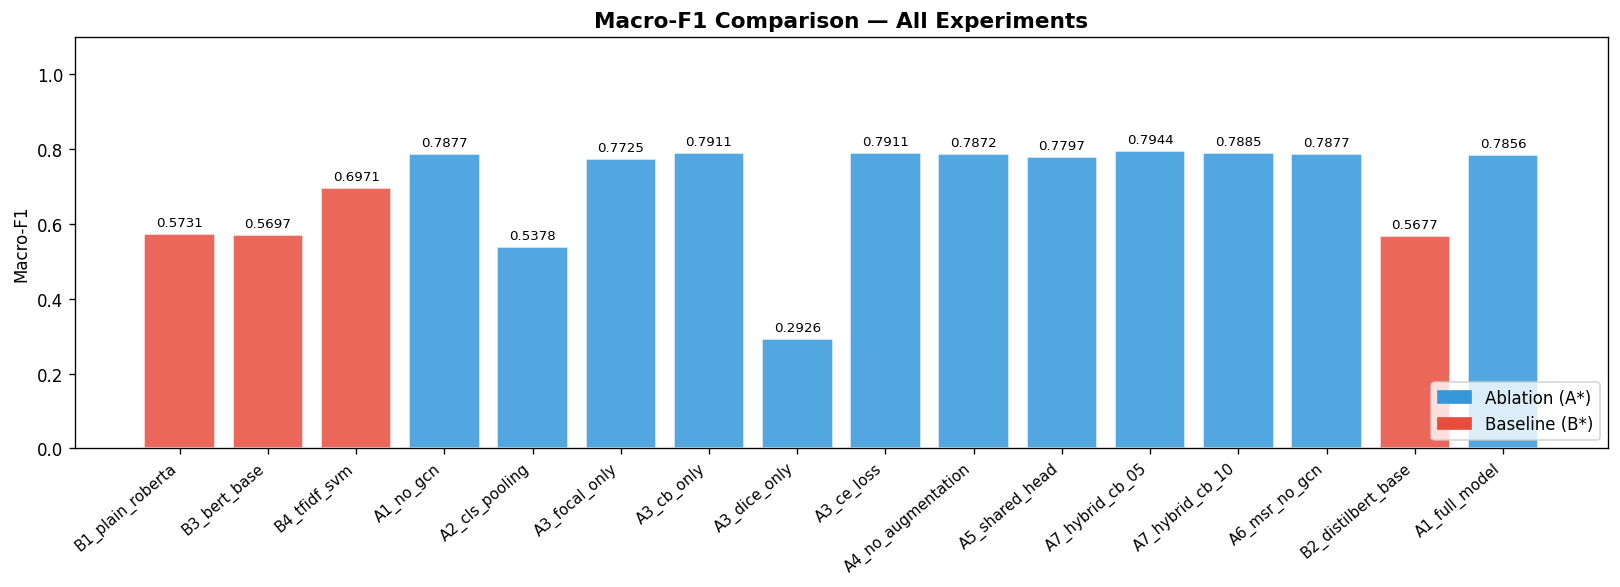

In [14]:
# Bar chart comparing Macro-F1 across all completed experiments.
# Blue bars = ablations (A*), Red bars = baselines (B*).
done   = df_results[df_results['Status'] == 'done']
colors = ['#3498db' if i.startswith('A') else '#e74c3c' for i in done.index]

fig, ax = plt.subplots(figsize=(max(10, len(done)*0.85), 5))
bars = ax.bar(done.index, done['Macro-F1'], color=colors, alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)  # Show exact values on top of bars
ax.set_ylim(0, 1.1); ax.set_ylabel('Macro-F1')
ax.set_title('Macro-F1 Comparison — All Experiments', fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db', label='Ablation (A*)'),
                   Patch(color='#e74c3c', label='Baseline (B*)')], loc='lower right')
plt.tight_layout(); plt.show()


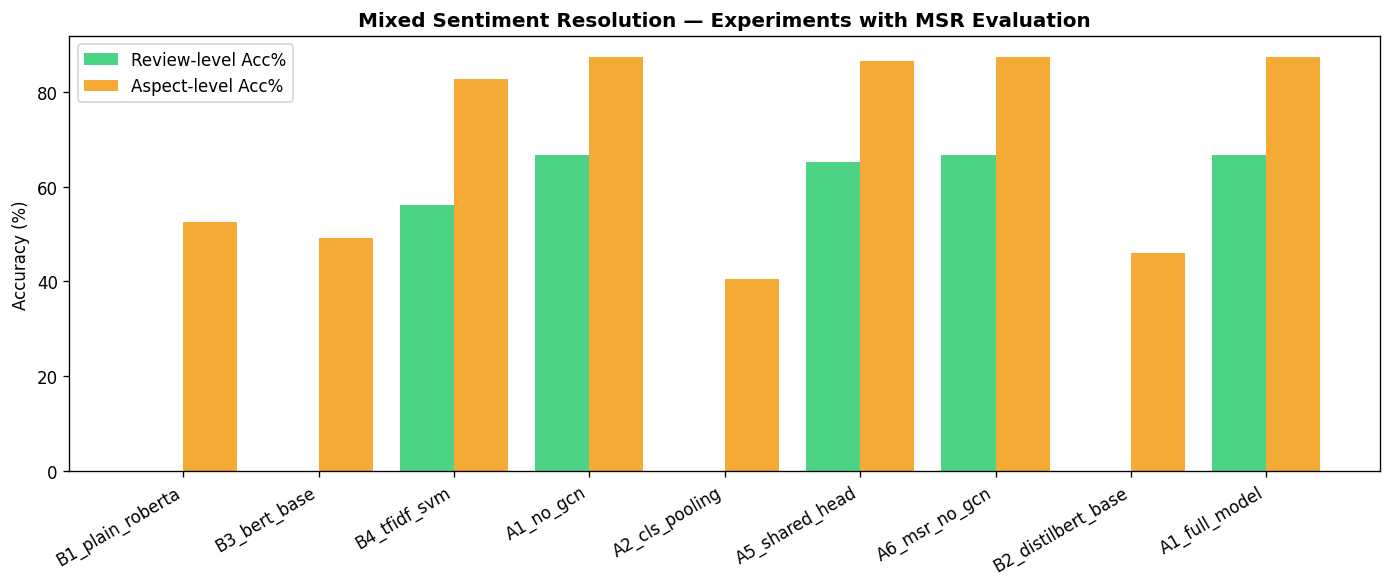

                    Review Acc%  Aspect Acc%
Experiment                                  
B1_plain_roberta       0.000000    52.594211
B3_bert_base           0.000000    49.098853
B4_tfidf_svm          56.050955    82.577826
A1_no_gcn             66.560510    87.329328
A2_cls_pooling         0.000000    40.578919
A5_shared_head        65.127389    86.510104
A6_msr_no_gcn         66.560510    87.329328
B2_distilbert_base     0.000000    46.095030
A1_full_model         66.560510    87.220098


In [15]:
# MSR comparison chart.
# Shows Review-level accuracy (did the model get ALL aspects right for a mixed review?)
# and Aspect-level accuracy (what % of individual aspects were correct in mixed reviews?)
# Only experiments that ran MSR evaluation (evaluate_msr=True) appear here.
msr_rows = [
    {'Experiment': eid,
     'Review Acc%': r['mixed_sentiment']['mixed_review_accuracy'],
     'Aspect Acc%': r['mixed_sentiment']['mixed_aspect_accuracy']}
    for eid, r in results.items()
    if r.get('status') == 'done' and r.get('mixed_sentiment', {}).get('mixed_review_count', 0) > 0
]
if msr_rows:
    df_msr = pd.DataFrame(msr_rows).set_index('Experiment')
    x = range(len(df_msr))
    fig, ax = plt.subplots(figsize=(max(8, len(df_msr)*1.3), 5))
    ax.bar([i-0.2 for i in x], df_msr['Review Acc%'], 0.4, label='Review-level Acc%', color='#2ecc71', alpha=0.85)
    ax.bar([i+0.2 for i in x], df_msr['Aspect Acc%'], 0.4, label='Aspect-level Acc%',  color='#f39c12', alpha=0.85)
    ax.set_xticks(list(x)); ax.set_xticklabels(df_msr.index, rotation=30, ha='right')
    ax.set_ylabel('Accuracy (%)'); ax.legend()
    ax.set_title('Mixed Sentiment Resolution — Experiments with MSR Evaluation', fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show(); print(df_msr.to_string())
else:
    print('No completed MSR experiments yet.')


In [16]:
# Generate a ready-to-paste LaTeX table for the FYP thesis report.
# Copy the printed output directly into your thesis .tex file.
done_ids = [eid for eid, r in results.items() if r.get('status') == 'done']
lines = [
    r'\begin{table}[h]', r'\centering',
    r'\caption{Ablation and Baseline Comparison Results}',
    r'\begin{tabular}{lcccccc}', r'\hline',
    r'Experiment & Accuracy & Macro-F1 & W-F1 & MCC & MSR-Review\% & MSR-Aspect\% \\',
    r'\hline',
]
for eid in done_ids:
    r  = results[eid]; ov = r.get('overall',{}); ms = r.get('mixed_sentiment',{})
    mrv = f"{ms['mixed_review_accuracy']:.2f}" if ms.get('mixed_review_count',0)>0 else '--'
    mas = f"{ms['mixed_aspect_accuracy']:.2f}"  if ms.get('mixed_review_count',0)>0 else '--'
    lines.append(f"{eid.replace('_',' ')} & {ov.get('accuracy',0):.4f} & "
                 f"{ov.get('macro_f1',0):.4f} & {ov.get('weighted_f1',0):.4f} & "
                 f"{ov.get('mcc',0):.4f} & {mrv} & {mas} \\\\")
lines += [r'\hline', r'\end{tabular}', r'\end{table}']
print('\n'.join(lines))


\begin{table}[h]
\centering
\caption{Ablation and Baseline Comparison Results}
\begin{tabular}{lcccccc}
\hline
Experiment & Accuracy & Macro-F1 & W-F1 & MCC & MSR-Review\% & MSR-Aspect\% \\
\hline
B1 plain roberta & 0.7754 & 0.5731 & 0.7827 & 0.4235 & 0.00 & 52.59 \\
B3 bert base & 0.7566 & 0.5697 & 0.7713 & 0.4398 & 0.00 & 49.10 \\
B4 tfidf svm & 0.8997 & 0.6971 & 0.8880 & 0.7023 & 56.05 & 82.58 \\
A1 no gcn & 0.9212 & 0.7877 & 0.9212 & 0.7799 & 66.56 & 87.33 \\
A2 cls pooling & 0.7317 & 0.5378 & 0.7507 & 0.4376 & 0.00 & 40.58 \\
A3 focal only & 0.9178 & 0.7725 & 0.9166 & 0.7731 & -- & -- \\
A3 cb only & 0.9250 & 0.7911 & 0.9246 & 0.7939 & -- & -- \\
A3 dice only & 0.7823 & 0.2926 & 0.6868 & 0.0000 & -- & -- \\
A3 ce loss & 0.9250 & 0.7911 & 0.9246 & 0.7939 & -- & -- \\
A4 no augmentation & 0.9245 & 0.7872 & 0.9225 & 0.7874 & -- & -- \\
A5 shared head & 0.9205 & 0.7797 & 0.9194 & 0.7778 & 65.13 & 86.51 \\
A7 hybrid cb 05 & 0.9247 & 0.7944 & 0.9236 & 0.7900 & -- & -- \\
A7 hybrid cb 10